Found 10016 files belonging to 5 classes.


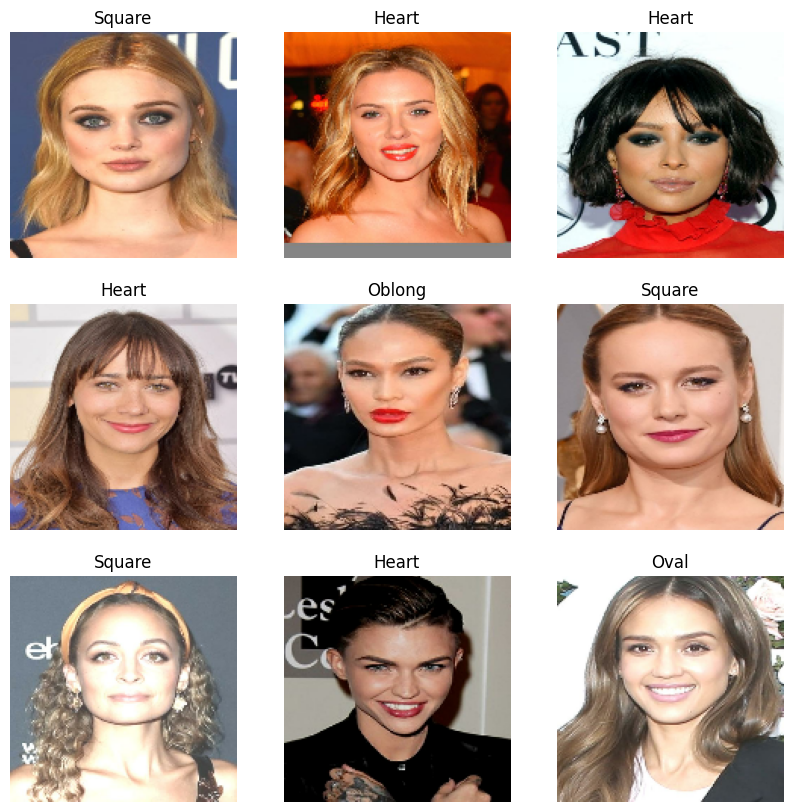

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Point to your folder
data_dir = "data/train/"

# 2. Load a small batch of images just to look at them
visualization_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(150, 150),
    batch_size=9 # We will grab 9 images
)

# Get the folder names (Oval, Round, etc.)
class_names = visualization_dataset.class_names

# 3. Draw a 3x3 grid of faces
plt.figure(figsize=(10, 10))
for images, labels in visualization_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]]) # Put the shape name above the picture
        plt.axis("off")
        
plt.show()

In [12]:
import os
from PIL import Image

# Point to your main folder
folder_path = "datasheets/training_set/"
sneaky_bad_files = []

print("🕵️‍♂️ Starting the DEEP CLEAN...")

# Walk through every folder and file
for root, dirs, files in os.walk(folder_path):
    for file in files:
        file_path = os.path.join(root, file)
        
        # 1. Skip hidden computer files (like .DS_Store on Mac or Thumbs.db on Windows)
        if file.startswith('.'):
            sneaky_bad_files.append(file_path)
            continue
            
        try:
            # 2. Open the image
            img = Image.open(file_path)
            
            # 3. THE MAGIC LINE: Force Python to read the actual pixels!
            img.load() 
            
            # 4. Make sure the image is in normal RGB colors 
            # (TensorFlow hates weird color formats like CMYK used for printing)
            if img.mode != "RGB":
                img = img.convert("RGB")
                
        except Exception as e:
            # If it fails to load the pixels, add it to the naughty list
            sneaky_bad_files.append(file_path)

print(f"\nDone scanning! Found {len(sneaky_bad_files)} sneaky bad files.")

# Delete the bad files
if len(sneaky_bad_files) > 0:
    print("🗑️ Deleting broken files...")
    for bad_file in sneaky_bad_files:
        try:
            os.remove(bad_file)
            print(f"Deleted: {bad_file}")
        except:
            print(f"⚠️ Could not delete {bad_file}. You might need to delete it manually.")
            
    print("\n✨ All clean! Go back up and try running your training cell (model.fit) one more time.")
else:
    print("\nHmm, no bad files found. The issue might be something else!")

🕵️‍♂️ Starting the DEEP CLEAN...

Done scanning! Found 0 sneaky bad files.

Hmm, no bad files found. The issue might be something else!


In [ ]:
# 1. Prepare the Textbook (Training) and Quiz (Validation)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123, image_size=(150, 150), batch_size=32)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123, image_size=(150, 150), batch_size=32)

# 2. Build the Model
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_names)) # Automatically counts your shape folders!
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 3. Train it! (Let's do 15 epochs to save time)
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=15)

# 4. Draw the Graphs!
plt.figure(figsize=(14, 5))

# Graph A: Accuracy (Higher is better)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy (Textbook)', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Quiz)', color='orange')
plt.title('Model Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Epoch')
plt.legend()

# Graph B: Loss/Mistakes (Lower is better)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Mistakes', color='blue')
plt.plot(history.history['val_loss'], label='Validation Mistakes', color='orange')
plt.title('Model Mistakes (Loss)')
plt.ylabel('Amount of Mistakes')
plt.xlabel('Epoch')
plt.legend()

plt.show()

Found 10016 files belonging to 5 classes.
Using 8013 files for training.
Found 10016 files belonging to 5 classes.
Using 2003 files for validation.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 245ms/step - accuracy: 0.3268 - loss: 2.2108 - val_accuracy: 0.3754 - val_loss: 1.4241
Epoch 2/15
  4/251 ━━━━━━━━━━━━━━━━━━━━ 39s 159ms/step - accuracy: 0.4792 - loss: 1.2554